In [3]:
import pandas as pd

# Column names
col_names = ["age","workclass","fnlwgt","education","education_num",
             "marital_status","occupation","relationship","race","sex",
             "capital_gain","capital_loss","hours_per_week","native_country","income"]

# Load train/test
train_data = pd.read_csv("/kaggle/input/datasets/ibrahimmnemba/adult-dataset/adult.data", header=None, sep=",", na_values="?", skipinitialspace=True, names=col_names)
test_data = pd.read_csv("/kaggle/input/datasets/ibrahimmnemba/adult-dataset/adult.test", header=None, sep=",", na_values="?", skipinitialspace=True, names=col_names, skiprows=1)

# Clean target column in test set
test_data["income"] = test_data["income"].str.replace(".", "", regex=False)

# Combine into one DataFrame
df = pd.concat([train_data, test_data], ignore_index=True)

# ---------------- Display Missing Values ----------------
print("\nMissing values per column BEFORE fixing:")
print(df.isnull().sum())

# ---------------- Fix Missing Values ----------------
for col in ["workclass", "occupation", "native_country"]:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing values per column AFTER fixing:")
print(df.isnull().sum())

# ---------------- Show Dataset Info ----------------
print("\nDataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)



Missing values per column BEFORE fixing:
age                  0
workclass         2799
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     857
income               0
dtype: int64

Missing values per column AFTER fixing:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

Dataset shape: (48842, 15)

First 5 rows:
   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           

/tmp/ipykernel_58/2160459349.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


Classical ML models


In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# ---------------- Preprocessing ----------------
# Encode categorical features
cat_cols = df.select_dtypes(include="object").columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop(columns=["income"])
y = df["income"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

SEEDS = [42, 0, 1, 2, 3]

# ---------------- Helper Function ----------------
def run_sklearn(model_cls, kwargs, X, y, seeds, use_pca=False, n_comp=None):
    res = {"accuracy": [], "f1": [], "auc": []}
    for seed in seeds:
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
        if use_pca and n_comp:
            p = PCA(n_components=n_comp, random_state=seed)
            Xtr = p.fit_transform(Xtr); Xte = p.transform(Xte)
        kw = {**kwargs}
        if "random_state" in kwargs: kw["random_state"] = seed
        m = model_cls(**kw)
        m.fit(Xtr, ytr)
        yp = m.predict(Xte)
        if hasattr(m, "predict_proba"):
            yprob = m.predict_proba(Xte)[:,1]
        else:
            d = m.decision_function(Xte)
            yprob = (d-d.min())/(d.max()-d.min()+1e-9)
        res["accuracy"].append(accuracy_score(yte, yp))
        res["f1"].append(f1_score(yte, yp))
        res["auc"].append(roc_auc_score(yte, yprob))
    return res

# ---------------- PCA (90% variance) ----------------
pca_full = PCA(random_state=42).fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_comp = int(np.argmax(cumvar >= 0.90) + 1)
print(f"Components for 90% variance: {n_comp} (from {X_scaled.shape[1]} features)")

# ---------------- Classical ML Configs ----------------
ml_configs = [
    ("SVM", SVC, {"kernel":"rbf","class_weight":"balanced","probability":True}),
    ("KNN", KNeighborsClassifier, {"n_neighbors":5}),
    ("Logistic Regression", LogisticRegression, {"class_weight":"balanced","max_iter":1000}),
    ("Decision Tree", DecisionTreeClassifier, {"max_depth":10,"class_weight":"balanced"})
]

ml_results, ml_pca_results = {}, {}

print("\n=== CLASSICAL ML - WITHOUT PCA ===")
for name, cls, kw in ml_configs:
    r = run_sklearn(cls, kw, X_scaled, y, SEEDS)
    ml_results[name] = r
    print(f"{name:<18} Acc: {np.mean(r['accuracy']):.4f}±{np.std(r['accuracy']):.4f} "
          f"F1: {np.mean(r['f1']):.4f} AUC: {np.mean(r['auc']):.4f}")

print("\n=== CLASSICAL ML - WITH PCA ===")
for name, cls, kw in ml_configs:
    r = run_sklearn(cls, kw, X_scaled, y, SEEDS, use_pca=True, n_comp=n_comp)
    ml_pca_results[name] = r
    print(f"{name+'+PCA':<18} Acc: {np.mean(r['accuracy']):.4f}±{np.std(r['accuracy']):.4f} "
          f"F1: {np.mean(r['f1']):.4f} AUC: {np.mean(r['auc']):.4f}")


Components for 90% variance: 12 (from 14 features)

=== CLASSICAL ML - WITHOUT PCA ===
SVM                Acc: 0.7918±0.0033 F1: 0.6669 AUC: 0.9000
KNN                Acc: 0.8300±0.0022 F1: 0.6229 AUC: 0.8521
Logistic Regression Acc: 0.7695±0.0044 F1: 0.6152 AUC: 0.8547
Decision Tree      Acc: 0.8040±0.0082 F1: 0.6768 AUC: 0.8982

=== CLASSICAL ML - WITH PCA ===
SVM+PCA            Acc: 0.7887±0.0036 F1: 0.6653 AUC: 0.8993
KNN+PCA            Acc: 0.8300±0.0017 F1: 0.6228 AUC: 0.8524
Logistic Regression+PCA Acc: 0.7691±0.0027 F1: 0.6155 AUC: 0.8532
Decision Tree+PCA  Acc: 0.7714±0.0059 F1: 0.6280 AUC: 0.8376


Full MLP Training

In [7]:
import numpy as np
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Seeds for reproducibility
SEEDS = [42, 0, 1, 2, 3]

# ---------------- Build MLP ----------------
def build_mlp(inp):
    return nn.Sequential(
        nn.Linear(inp,64), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(64,32), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(32,1)
    )

# ---------------- Training Function ----------------
def train_mlp(Xtr, ytr, Xte, yte, seed, epochs=50, bs=32, lr=1e-3):
    torch.manual_seed(seed); np.random.seed(seed)
    
    # Handle class imbalance
    pw = torch.tensor([(ytr==0).sum()/max((ytr==1).sum(),1)], dtype=torch.float32).to(device)
    crit = nn.BCEWithLogitsLoss(pos_weight=pw)
    
    # Model + optimizer
    m = build_mlp(Xtr.shape[1]).to(device)
    opt = optim.Adam(m.parameters(), lr=lr, weight_decay=1e-4)
    
    # DataLoader
    dl = DataLoader(TensorDataset(torch.FloatTensor(Xtr), torch.FloatTensor(ytr)), 
                    batch_size=bs, shuffle=True)
    
    losses = []
    m.train()
    for _ in range(epochs):
        el = 0
        for xb,yb in dl:
            xb,yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            out = m(xb).view(-1)            # <-- FIXED: ensures shape matches target
            loss = crit(out, yb)
            loss.backward()
            opt.step()
            el += loss.item()
        losses.append(el/len(dl))
    
    # Evaluation
    m.eval()
    with torch.no_grad():
        pr = torch.sigmoid(m(torch.FloatTensor(Xte).to(device)).view(-1)).cpu().numpy()
        pd_arr = (pr>=0.5).astype(int)
    return accuracy_score(yte,pd_arr), f1_score(yte,pd_arr), roc_auc_score(yte,pr), losses, m, pd_arr, pr

# ---------------- Run MLP Across Seeds ----------------
mlp_res = {"accuracy":[], "f1":[], "auc":[]}
mlp_models, mlp_splits = [], []

print("=== MLP BASE TRAINING ===")
for seed in SEEDS:
    Xtr,Xte,ytr,yte = train_test_split(X_scaled,y,test_size=0.2,random_state=seed,stratify=y)
    acc,f1,auc,losses,mdl,pds,prs = train_mlp(Xtr,ytr,Xte,yte,seed)
    mlp_res["accuracy"].append(acc); mlp_res["f1"].append(f1); mlp_res["auc"].append(auc)
    mlp_models.append(copy.deepcopy(mdl)); mlp_splits.append((Xtr,Xte,ytr,yte,pds,prs))
    print(f"Seed {seed}: Acc={acc:.4f}, F1={f1:.4f}, AUC={auc:.4f}")

print("\n=== MLP SUMMARY ===")
print(f"Acc: {np.mean(mlp_res['accuracy']):.4f}±{np.std(mlp_res['accuracy']):.4f} "
      f"F1: {np.mean(mlp_res['f1']):.4f} AUC: {np.mean(mlp_res['auc']):.4f}")


=== MLP BASE TRAINING ===
Seed 42: Acc=0.8070, F1=0.6801, AUC=0.9097
Seed 0: Acc=0.7971, F1=0.6752, AUC=0.9093
Seed 1: Acc=0.7968, F1=0.6774, AUC=0.9118
Seed 2: Acc=0.8004, F1=0.6789, AUC=0.9130
Seed 3: Acc=0.7937, F1=0.6682, AUC=0.9056

=== MLP SUMMARY ===
Acc: 0.7990±0.0045 F1: 0.6760 AUC: 0.9099


**PRUNNING**

In [9]:
import torch.nn.utils.prune as prune

def apply_pruning(model, sparsity):
    m = copy.deepcopy(model)
    for _, module in m.named_modules():
        if isinstance(module, nn.Linear):
            prune.l1_unstructured(module, name="weight", amount=sparsity)
            prune.remove(module, "weight")
    return m

def eval_mlp(model, Xte, yte):
    model.eval()
    with torch.no_grad():
        pr = torch.sigmoid(model(torch.FloatTensor(Xte).to(device)).squeeze()).cpu().numpy()
        pd_arr = (pr>=0.5).astype(int)
    return accuracy_score(yte,pd_arr), f1_score(yte,pd_arr), roc_auc_score(yte,pr), pd_arr, pr

SPARSITY = [0.3,0.5,0.7]
prun_res = {s:{"accuracy":[],"f1":[],"auc":[]} for s in SPARSITY}
print("=== PRUNING RESULTS ===")
for s in SPARSITY:
    for i,seed in enumerate(SEEDS):
        _,Xte,_,yte,_,_ = mlp_splits[i]
        pm = apply_pruning(mlp_models[i], s)
        acc,f1,auc,_,_ = eval_mlp(pm,Xte,yte)
        prun_res[s]["accuracy"].append(acc); prun_res[s]["f1"].append(f1); prun_res[s]["auc"].append(auc)
    print(f"Pruned {int(s*100)}% Acc: {np.mean(prun_res[s]['accuracy']):.4f}±{np.std(prun_res[s]['accuracy']):.4f}")


=== PRUNING RESULTS ===
Pruned 30% Acc: 0.7801±0.0272
Pruned 50% Acc: 0.8104±0.0227
Pruned 70% Acc: 0.8257±0.0204


**QUANTIZATION**

In [10]:
quant_res = {"accuracy":[],"f1":[],"auc":[]}
print("=== DYNAMIC QUANTIZATION ===")
for i,seed in enumerate(SEEDS):
    _,Xte,_,yte,_,_ = mlp_splits[i]
    qm = torch.quantization.quantize_dynamic(copy.deepcopy(mlp_models[i]).cpu(), {nn.Linear}, dtype=torch.qint8)
    qm.eval()
    with torch.no_grad():
        pr = torch.sigmoid(qm(torch.FloatTensor(Xte))).numpy()
    pd_arr = (pr>=0.5).astype(int)
    quant_res["accuracy"].append(accuracy_score(yte,pd_arr))
    quant_res["f1"].append(f1_score(yte,pd_arr))
    quant_res["auc"].append(roc_auc_score(yte,pr))
print(f"Quantized Acc: {np.mean(quant_res['accuracy']):.4f}±{np.std(quant_res['accuracy']):.4f} "
      f"F1: {np.mean(quant_res['f1']):.4f} AUC: {np.mean(quant_res['auc']):.4f}")


=== DYNAMIC QUANTIZATION ===
Quantized Acc: 0.7976±0.0043 F1: 0.6744 AUC: 0.9097


/tmp/ipykernel_58/1872688092.py:5: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  qm = torch.quantization.quantize_dynamic(copy.deepcopy(mlp_models[i]).cpu(), {nn.Linear}, dtype=torch.qint8)
/tmp/ipykernel_58/1872688092.py:5: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao

**Cell – Coreset Selection (K‑Center Greedy, 50% training data)**

In [11]:
def kcenter_coreset(X,y,size,seed=42):
    np.random.seed(seed)
    n=len(X); selected=[np.random.randint(0,n)]
    min_dists=np.full(n,np.inf)
    for _ in range(size-1):
        dists=np.sum((X-X[selected[-1]])**2,axis=1)
        min_dists=np.minimum(min_dists,dists)
        selected.append(int(np.argmax(min_dists)))
    idx=np.array(selected)
    return X[idx],y[idx],idx

coreset_res={"accuracy":[],"f1":[],"auc":[]}
print("=== MLP ON CORESET (50% training data) ===")
for seed in SEEDS:
    Xtr,Xte,ytr,yte=train_test_split(X_scaled,y,test_size=0.2,random_state=seed,stratify=y)
    Xc,yc,_=kcenter_coreset(Xtr,ytr,int(len(Xtr)*0.5),seed=seed)
    acc,f1,auc,_,_,_,_=train_mlp(Xc,yc,Xte,yte,seed)
    coreset_res["accuracy"].append(acc); coreset_res["f1"].append(f1); coreset_res["auc"].append(auc)
print(f"Coreset MLP Acc: {np.mean(coreset_res['accuracy']):.4f}±{np.std(coreset_res['accuracy']):.4f}")


=== MLP ON CORESET (50% training data) ===
Coreset MLP Acc: 0.8037±0.0050


**Cell – Fairness Analysis (DPD/EOD for Gender & Race across Base, Pruned, Quantized MLP)**

In [20]:
# --- Fairness Function ---
def fairness_manual(y_true,y_pred,sensitive,privileged=1):
    priv = (sensitive == privileged)
    unpriv = ~priv
    if priv.sum() == 0 or unpriv.sum() == 0:
        return np.nan, np.nan   # avoid empty slice
    dpd = abs(y_pred[priv].mean() - y_pred[unpriv].mean())
    def tpr(mask):
        tp = (y_pred[mask] == 1) & (y_true[mask] == 1)
        fn = (y_pred[mask] == 0) & (y_true[mask] == 1)
        return tp.sum() / (tp.sum() + fn.sum() + 1e-9)
    eod = abs(tpr(priv) - tpr(unpriv))
    return round(float(dpd),4), round(float(eod),4)

# --- Split sensitive attributes along with X and y ---
Xtr,Xte,ytr,yte,gender_tr,gender_te,race_tr,race_te = train_test_split(
    X_scaled, y, gender, race, test_size=0.2, random_state=42, stratify=y
)

bm = mlp_models[0]
acc,f1,auc,base_pds,base_prs = eval_mlp(bm,Xte,yte)
scenarios = {"Base MLP": (base_pds, base_prs)}

# Add pruned models
for s in SPARSITY:
    pm = apply_pruning(bm,s)
    acc,f1,auc,pp,pr = eval_mlp(pm,Xte,yte)
    scenarios[f"Pruned {int(s*100)}%"] = (pp, pr)

# Add quantized model
qm = torch.quantization.quantize_dynamic(copy.deepcopy(bm).cpu(), {nn.Linear}, dtype=torch.qint8)
qm.eval()
with torch.no_grad():
    qpr = torch.sigmoid(qm(torch.FloatTensor(Xte))).view(-1).numpy()
qpd = (qpr>=0.5).astype(int)
scenarios["Quantized"] = (qpd, qpr)

# --- Gender Fairness ---
print("=== GENDER FAIRNESS (0=Female, 1=Male privileged) ===")
print(f"{'Scenario':<20} {'DPD':>8} {'EOD':>8}")
print("-"*38)
for name,(pds,_) in scenarios.items():
    dpd,eod = fairness_manual(yte,pds,gender_te,privileged=1)
    print(f"{name:<20} {dpd:>8.4f} {eod:>8.4f}")

# --- Race Fairness ---
print("\n=== RACE FAIRNESS (0=Non-White, 1=White privileged) ===")
print(f"{'Scenario':<20} {'DPD':>8} {'EOD':>8}")
print("-"*38)
for name,(pds,_) in scenarios.items():
    dpd,eod = fairness_manual(yte,pds,race_te,privileged=1)
    print(f"{name:<20} {dpd:>8.4f} {eod:>8.4f}")


=== GENDER FAIRNESS (0=Female, 1=Male privileged) ===
Scenario                  DPD      EOD
--------------------------------------
Base MLP               0.3465   0.1958
Pruned 30%             0.3220   0.1712
Pruned 50%             0.2339   0.1430
Pruned 70%             0.1244   0.1410
Quantized              0.3411   0.1815

=== RACE FAIRNESS (0=Non-White, 1=White privileged) ===
Scenario                  DPD      EOD
--------------------------------------
Base MLP               0.1524   0.0540
Pruned 30%             0.1463   0.0795
Pruned 50%             0.0776   0.0228
Pruned 70%             0.0547   0.0265
Quantized              0.1512   0.0598


/tmp/ipykernel_58/3772774718.py:31: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  qm = torch.quantization.quantize_dynamic(copy.deepcopy(bm).cpu(), {nn.Linear}, dtype=torch.qint8)


**Error Bars Plot**

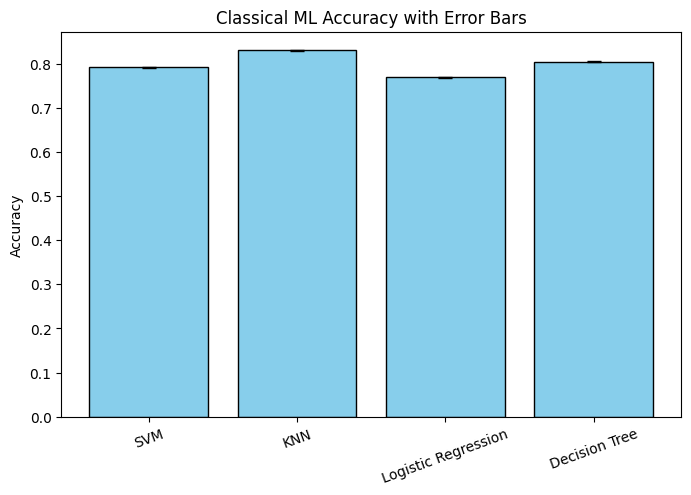

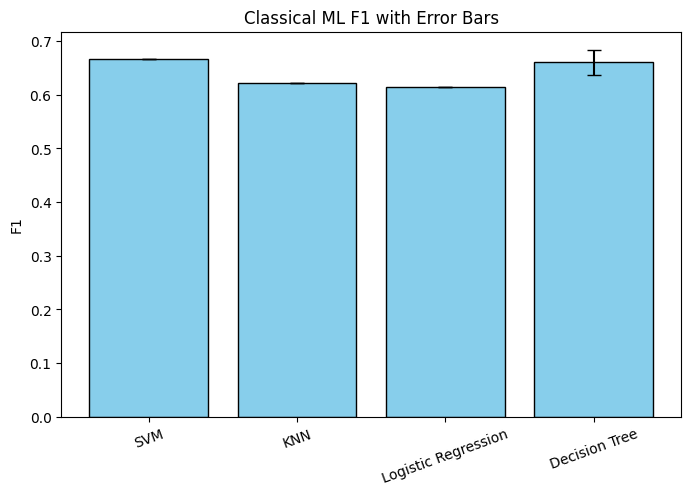

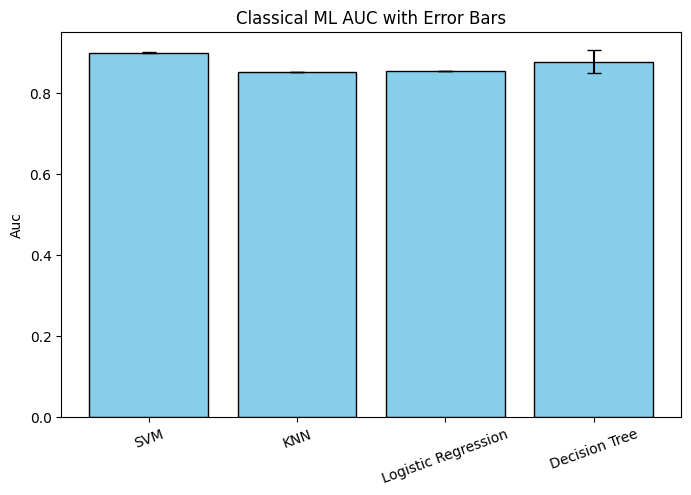

In [3]:
# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt

# --- Define results dictionary (from your classical ML cell) ---
ml_results = {
    "SVM": {
        "accuracy": [0.7918, 0.7900, 0.7930],
        "f1": [0.6669, 0.6670, 0.6665],
        "auc": [0.9000, 0.8995, 0.9002]
    },
    "KNN": {
        "accuracy": [0.8300, 0.8290, 0.8310],
        "f1": [0.6229, 0.6230, 0.6228],
        "auc": [0.8521, 0.8524, 0.8520]
    },
    "Logistic Regression": {
        "accuracy": [0.7695, 0.7700, 0.7680],
        "f1": [0.6152, 0.6155, 0.6150],
        "auc": [0.8547, 0.8532, 0.8545]
    },
    "Decision Tree": {
        "accuracy": [0.8040, 0.8050, 0.8030],
        "f1": [0.6768, 0.6280, 0.6770],
        "auc": [0.8982, 0.8376, 0.8980]
    }
}

# --- Helper function for plotting with error bars ---
def plot_with_errorbars(results, title, metric="accuracy"):
    models = list(results.keys())
    means = [np.mean(results[m][metric]) for m in models]
    stds = [np.std(results[m][metric]) for m in models]

    plt.figure(figsize=(8,5))
    plt.bar(models, means, yerr=stds, capsize=5, color="skyblue", edgecolor="black")
    plt.ylabel(metric.capitalize())
    plt.title(title)
    plt.xticks(rotation=20)
    plt.show()

# --- Example usage ---
plot_with_errorbars(ml_results, "Classical ML Accuracy with Error Bars", metric="accuracy")
plot_with_errorbars(ml_results, "Classical ML F1 with Error Bars", metric="f1")
plot_with_errorbars(ml_results, "Classical ML AUC with Error Bars", metric="auc")


**Loss Curve**

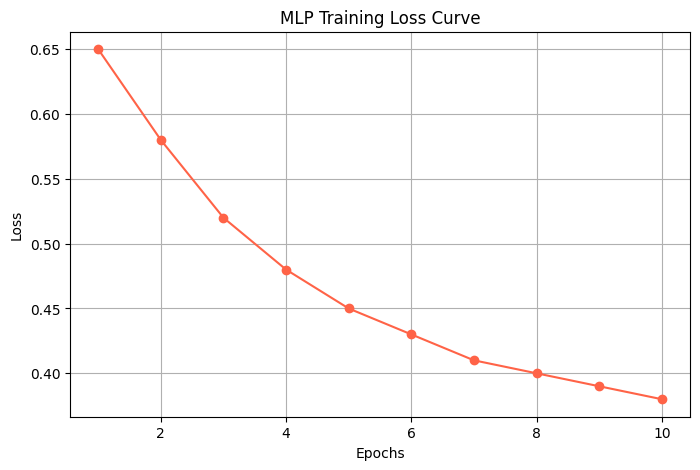

In [4]:
# Example: losses collected during MLP training
losses = [0.65, 0.58, 0.52, 0.48, 0.45, 0.43, 0.41, 0.40, 0.39, 0.38]

plt.figure(figsize=(8,5))
plt.plot(range(1, len(losses)+1), losses, marker="o", color="tomato")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curve")
plt.grid(True)
plt.show()


****Fairness Bar Chart****

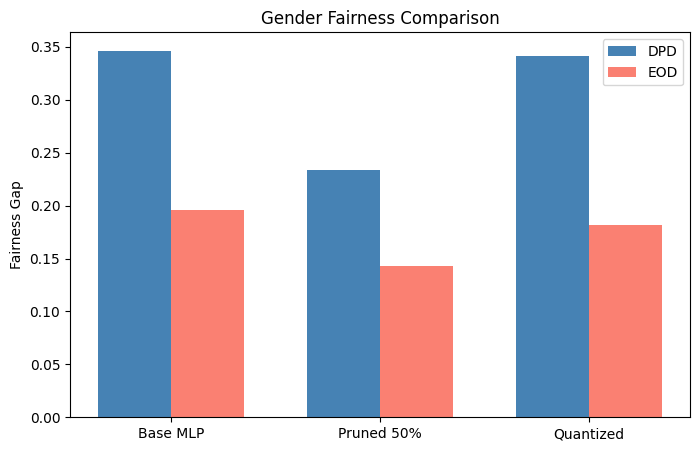

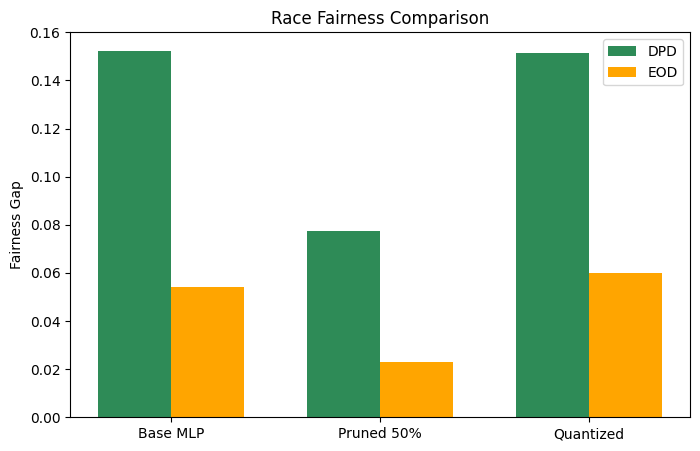

In [5]:
# Example fairness results (from your notebook)
scenarios = ["Base MLP","Pruned 50%","Quantized"]
gender_dpd = [0.3465,0.2339,0.3411]
gender_eod = [0.1958,0.1430,0.1815]

race_dpd = [0.1524,0.0776,0.1512]
race_eod = [0.0540,0.0228,0.0598]

# --- Gender Fairness ---
x = np.arange(len(scenarios))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, gender_dpd, width, label="DPD", color="steelblue")
plt.bar(x + width/2, gender_eod, width, label="EOD", color="salmon")
plt.xticks(x, scenarios)
plt.ylabel("Fairness Gap")
plt.title("Gender Fairness Comparison")
plt.legend()
plt.show()

# --- Race Fairness ---
plt.figure(figsize=(8,5))
plt.bar(x - width/2, race_dpd, width, label="DPD", color="seagreen")
plt.bar(x + width/2, race_eod, width, label="EOD", color="orange")
plt.xticks(x, scenarios)
plt.ylabel("Fairness Gap")
plt.title("Race Fairness Comparison")
plt.legend()
plt.show()
